# Как узнать свою аудиторию? Построение различных вариантов кластеризаций и интерпретация результатов.
На этот раз займемся классической задачкой - сегментация клиентов (в данном случае - банка). Крайне полезная операция, которая позволяет вам лучше познакомиться со своей аудиторией, понять, на какие группы она делится и чем они характеризуются.

## Часть 1. EDA и Preprocessing.
* Скачайте данные по клиентам немецкого банка: https://www.kaggle.com/uciml/german-credit;
* Проведите EDA, чтобы познакомиться с признаками;
* Преобразуйте все признаки в числовые подходящими методами;
* Приведите все данные к одному масштабу (а заодно поясните, почему это необходимая операция при кластеризации).

## Часть 2. Моделирование.
* Постройте три варианта кластеризации: k-means, hierarhical и DBSCAN, подберите оптимальное количество кластеров для каждого метода при помощи Elbow method и Silhouette plot;
* Также воспользуйтесь различными вариантами сжатия признакового пространства (PCA, UMAP, tSNE) и визуализируйте результаты кластеризации на двумерной плоскости.

## Часть 3. Интерпретация.
* Теперь ваша задача - попытаться проинтерпретировать получившиеся кластеры, начните с простого расчета средних значений признаков для каждого из кластеров, есть ли интересные закономерности?
* Теперь постройте boxplot-ы для каждого признака, сгруппировав значения по кластерам, по каким признакам заметно наибольшее отличие кластеров друг от друга? Можно ли их интерпретировать?

In [33]:
pip install umap-learn

Note: you may need to restart the kernel to use updated packages.


In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA
from umap import UMAP
from sklearn.manifold import TSNE

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from sklearn.cluster import DBSCAN

In [35]:
dataset_customer = pd.read_csv("HW2(lesson10)_data.csv")

# Разведочный анализ данных

In [36]:
dataset_customer.head(3).T

,0,1,2
Unnamed: 0,0,1,2
Age,67,22,49
Sex,male,female,male
Job,2,2,1
Housing,own,own,own
Saving accounts,NaN,little,little
Checking account,little,moderate,NaN
Credit amount,1169,5951,2096
Duration,6,48,12
Purpose,radio/TV,radio/TV,education


In [37]:
# сразу удаляем неинформативные поля
dataset_customer = dataset_customer.drop(["Unnamed: 0"], axis="columns")

In [38]:
dataset_customer.isnull().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

Пропуски есть с ними нужно будет что-то делать

In [39]:
for col in dataset_customer.select_dtypes(include=["object", "str"]).columns:
    print(f"{col}: {dataset_customer[col].unique().shape[0]} {dataset_customer[col].unique()}\n")

Sex: 2 <StringArray>
['male', 'female']
Length: 2, dtype: str

Housing: 3 <StringArray>
['own', 'free', 'rent']
Length: 3, dtype: str

Saving accounts: 5 <StringArray>
[nan, 'little', 'quite rich', 'rich', 'moderate']
Length: 5, dtype: str

Checking account: 4 <StringArray>
['little', 'moderate', nan, 'rich']
Length: 4, dtype: str

Purpose: 8 <StringArray>
[           'radio/TV',           'education', 'furniture/equipment',
                 'car',            'business', 'domestic appliances',
             'repairs',     'vacation/others']
Length: 8, dtype: str



In [40]:
# Пропуски в enum полях, и в целом их можно заполнить новым значением
dataset_customer["Saving accounts"] = dataset_customer["Saving accounts"].fillna("nothing")
dataset_customer["Checking account"] = dataset_customer["Checking account"].fillna("nothing")

In [41]:
dataset_customer.select_dtypes(include=["number"]).info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Age            1000 non-null   int64
 1   Job            1000 non-null   int64
 2   Credit amount  1000 non-null   int64
 3   Duration       1000 non-null   int64
dtypes: int64(4)
memory usage: 31.4 KB


In [42]:
dataset_customer.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
Job,1000.0,1.904,0.653614,0.0,2.0,2.0,2.00,3.0
Credit amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0


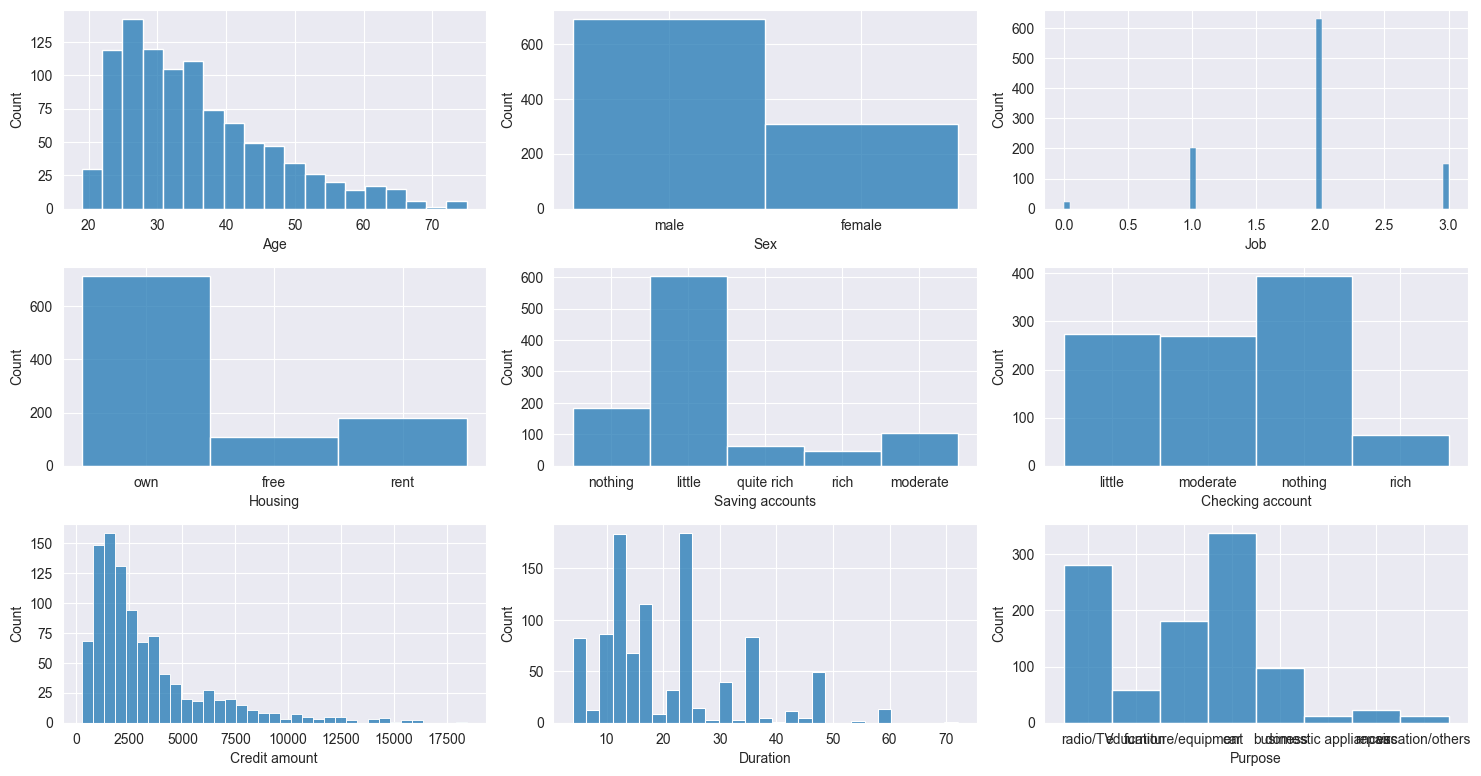

In [43]:
features_lst = dataset_customer.columns.to_list()

plt_col_count = 3
plt_row_count = 1 + int(len(features_lst) / plt_col_count)
fig, axes = plt.subplots(plt_row_count, plt_col_count, figsize=(15, 10))
axes_iter = axes.flat

for field in features_lst:
    axis = next(axes_iter)
    sns.histplot(dataset_customer, x = field,
                 element = "bars", stat = "count", ax = axis, legend = False)
    # axis.set_title(field)
# удаляем незадействованные оси
for axis in axes_iter:
    fig.delaxes(axis)

# графики мы подписали, теперь нужно место для title
plt.tight_layout()
plt.show()

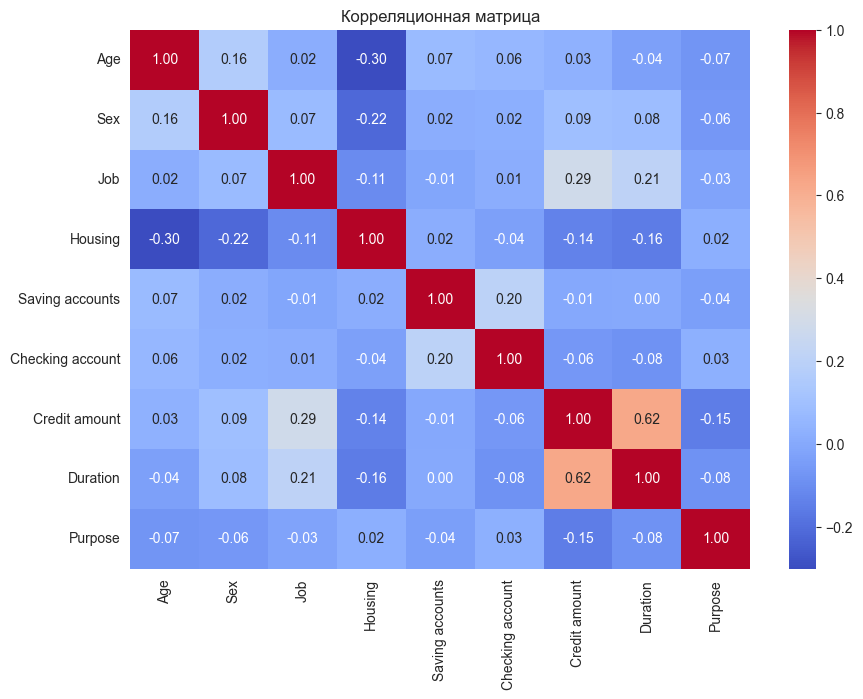

In [44]:
# предварительно преобразуем строковые поля для расчета корреляции
le = LabelEncoder()
dataset_label = dataset_customer.copy()
for col in dataset_label.select_dtypes(include=["object", "str"]).columns:
    dataset_label[col] = le.fit_transform(dataset_label[col])
# затем считаем корреляцию
dataset_corr = dataset_label.corr()
plt.figure(figsize=(10, 7))
sns.heatmap(dataset_corr, fmt= ".2f", annot = True, cmap = "coolwarm")
plt.title("Корреляционная матрица")
plt.show()

Максимальная корреляция 0.62 - удалять ничего не будем

# Моделирование

## Подготовка данных

модели работают с расстояниями, поэтому все категориальные признаки необходимо перевести в числовые

In [45]:
dataset_num = dataset_customer.copy()

# поле пола заменяем бинарным признаком
dataset_num["Sex"] = OneHotEncoder(sparse_output=False, drop="first").fit_transform(dataset_num[["Sex"]])

# поля Housing, Saving accounts и Checking account можно считать упорядоченными
# (клиент имеющий свой дом, явно предпочтительнее для банка чем снимающий жилье)
# эти поля заменяем по словарю
dataset_num["Housing"] = OrdinalEncoder(categories=[["free", "rent", "own"]]).fit_transform(dataset_num[["Housing"]])
dataset_num["Saving accounts"] = \
    (OrdinalEncoder(categories=[["nothing", "little", "moderate", "quite rich", "rich"]]).
     fit_transform(dataset_num[["Saving accounts"]]))
dataset_num["Checking account"] = \
    (OrdinalEncoder(categories=[["nothing", "little", "moderate", "rich"]]).
     fit_transform(dataset_num[["Checking account"]]))

# поле Purpose в целом можно попробовать отсортировать, но менее однозначно, поэтому просто кодируем OneHotEncoder
encoder_cat_purpose = OneHotEncoder(sparse_output=False)
dataset_num[encoder_cat_purpose.get_feature_names_out()] = encoder_cat_purpose.fit_transform(dataset_num[["Purpose"]])
dataset_num = dataset_num.drop(["Purpose"], axis="columns")

после этого все признаки требуется нормализовать, что бы расстояния по одному параметру не доминировали (поэтому используем MinMaxScaler дающий предсказуемый результат)

In [46]:
features_lst = dataset_num.select_dtypes(include=np.number).columns.tolist()
for feature in features_lst:
    dataset_num[feature] = MinMaxScaler().fit_transform(dataset_num[[feature]])

## Снижение размерности

In [47]:
reduction_methods = {
    "tSNE": TSNE(n_components=2, random_state = 42),
    "PCA": PCA(n_components=2, random_state = 42),
    "UMAP": UMAP(n_components=2, random_state = 42),
}
clustering_results = {
}

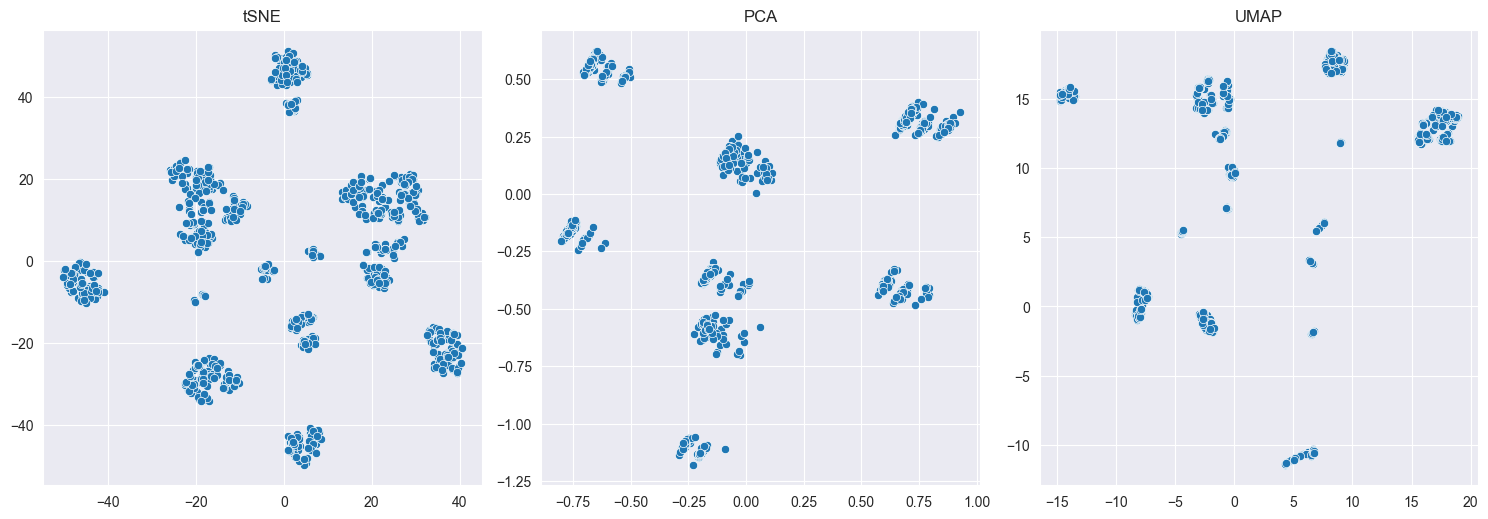

In [61]:
plt_col_count = len(reduction_methods)
plt_row_count = 1 + int(len(reduction_methods) / plt_col_count)
fig, axes = plt.subplots(plt_row_count, plt_col_count, figsize=(15, 10))
axes_iter = axes.flat
for method_name, method in reduction_methods.items():
    axis = next(axes_iter)
    X = method.fit_transform(dataset_num)
    sns.scatterplot(x=X[:,0], y=X[:,1], ax=axis)
    axis.set_title(method_name)
# удаляем незадействованные оси
for axis in axes_iter:
    fig.delaxes(axis)
# графики мы подписали, теперь нужно место для title
plt.tight_layout()
plt.show()

на плоскости кажется что кластеры вполне различимы. посмотрим что в исходном пространстве

## Кластеризация

### KMeans

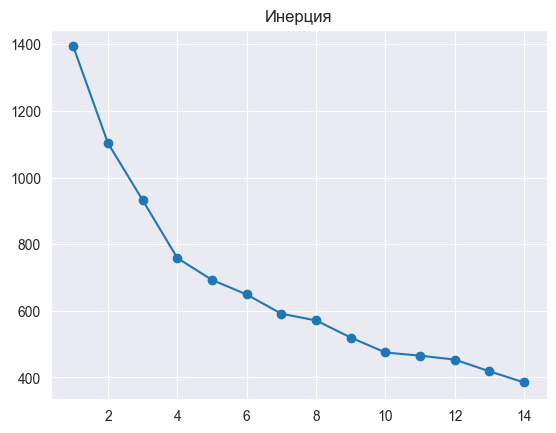

In [49]:
MAX_CLUSTER_COUNT = 15
inertia = []
for cluster_count in range(1, MAX_CLUSTER_COUNT):
    kmeans = KMeans(n_clusters=cluster_count, random_state=42).fit(dataset_num)
    inertia.append(kmeans.inertia_)
plt.plot(range(1, MAX_CLUSTER_COUNT), inertia, marker="o")
plt.title("Инерция")
plt.show()

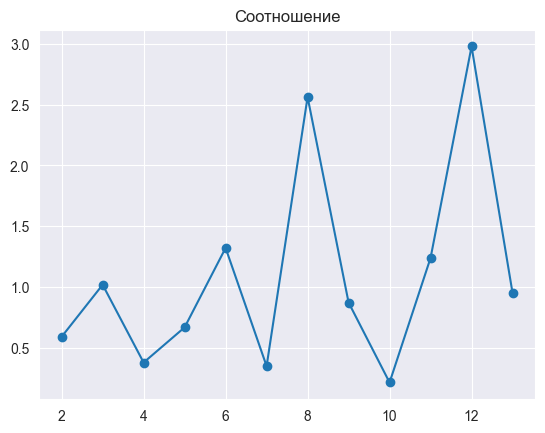

In [50]:
D = [(inertia[i] - inertia[i+1])/(inertia[i-1] - inertia[i]) for i in range(1, MAX_CLUSTER_COUNT - 2)]
plt.plot(range(2, MAX_CLUSTER_COUNT - 1), D, marker="o")
plt.title("Соотношение")
plt.show()

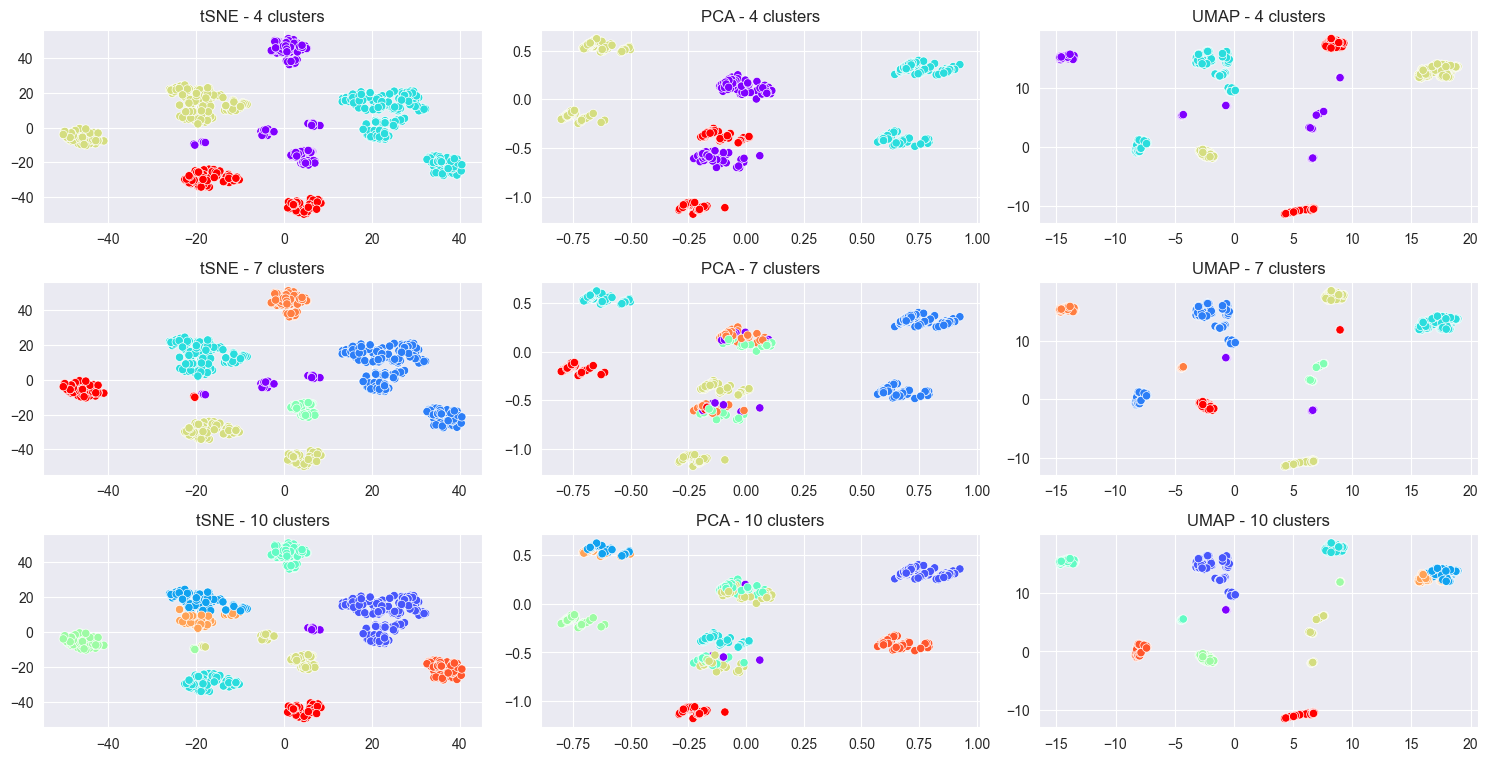

In [51]:
# выбор стоит из 4, 7 либо 10 кластеров
cluster_coll = [4, 7, 10]
clustering_results["KMeans"] = {}

plt_col_count = len(reduction_methods)
plt_row_count = 1 + int(len(reduction_methods) * len(cluster_coll) / plt_col_count)
fig, axes = plt.subplots(plt_row_count, plt_col_count, figsize=(15, 10))
axes_iter = axes.flat
for cluster_count in cluster_coll:
    labels = KMeans(n_clusters=cluster_count, random_state=42).fit(dataset_num).labels_
    clustering_results["KMeans"][cluster_count] = labels
    for method_name, method in reduction_methods.items():
        axis = next(axes_iter)
        X = method.fit_transform(dataset_num)
        sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels, ax=axis, palette="rainbow", legend=False)
        axis.set_title(f"{method_name} - {cluster_count} clusters")
# удаляем незадействованные оси
for axis in axes_iter:
    fig.delaxes(axis)
# графики мы подписали, теперь нужно место для title
plt.tight_layout()
plt.show()

5 кластеров явно недостатно.

между 7 и 10 кластерами я бы выбрал 7, поскольку уже пошло не только выделение отдельно лежащих областей, но и деление близких зон (снижение размерности явно не проходит даром)

### Hierarhical

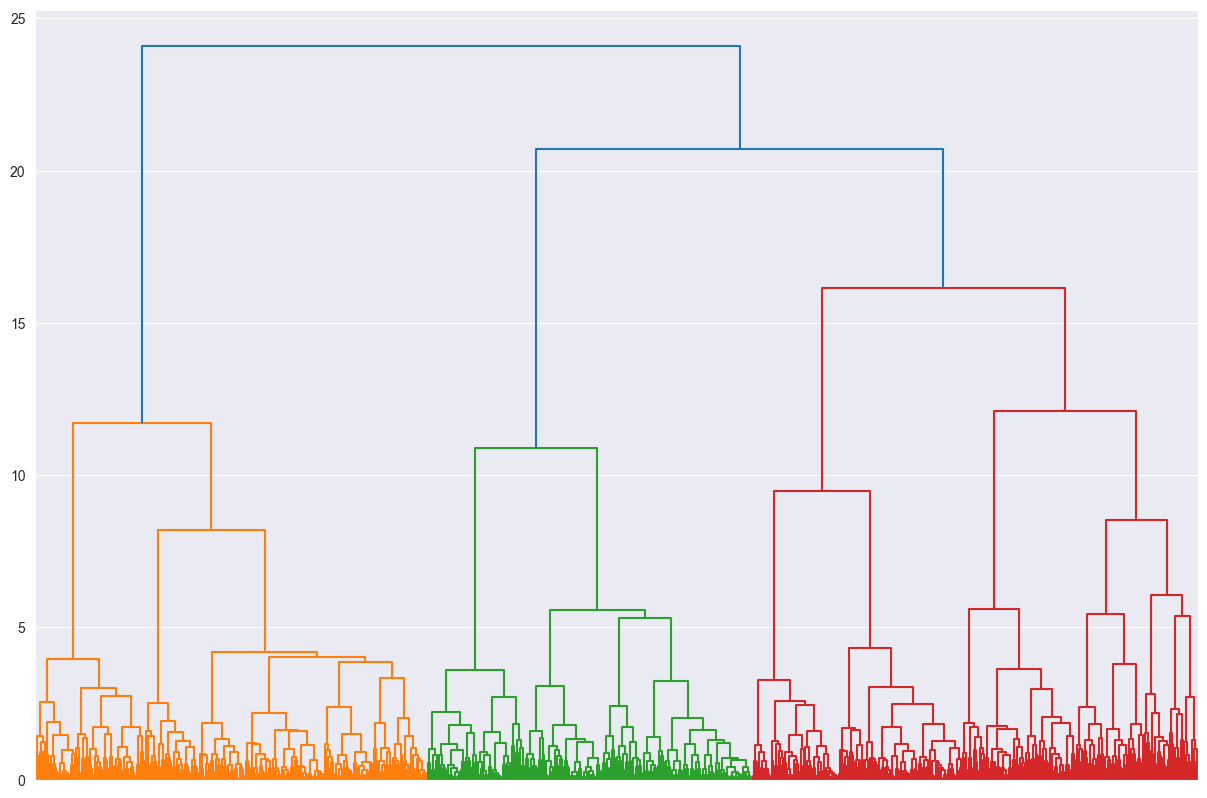

In [52]:
plt.figure(figsize=(15, 10))
linkage_ = linkage(dataset_num, method="ward")
dendrogram_ = dendrogram(linkage_, no_labels=True)

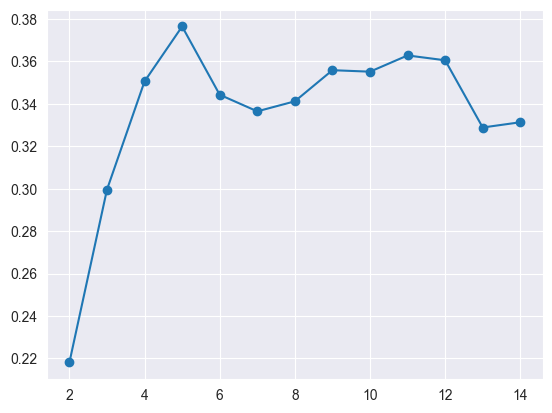

In [53]:
silhouette = []
for cluster_count in range(2, MAX_CLUSTER_COUNT):
    agg = AgglomerativeClustering(n_clusters=cluster_count).fit(dataset_num)
    labels = agg.labels_
    score = silhouette_score(dataset_num, labels)
    silhouette.append(score)
plt.plot(range(2, MAX_CLUSTER_COUNT), silhouette, marker="o");

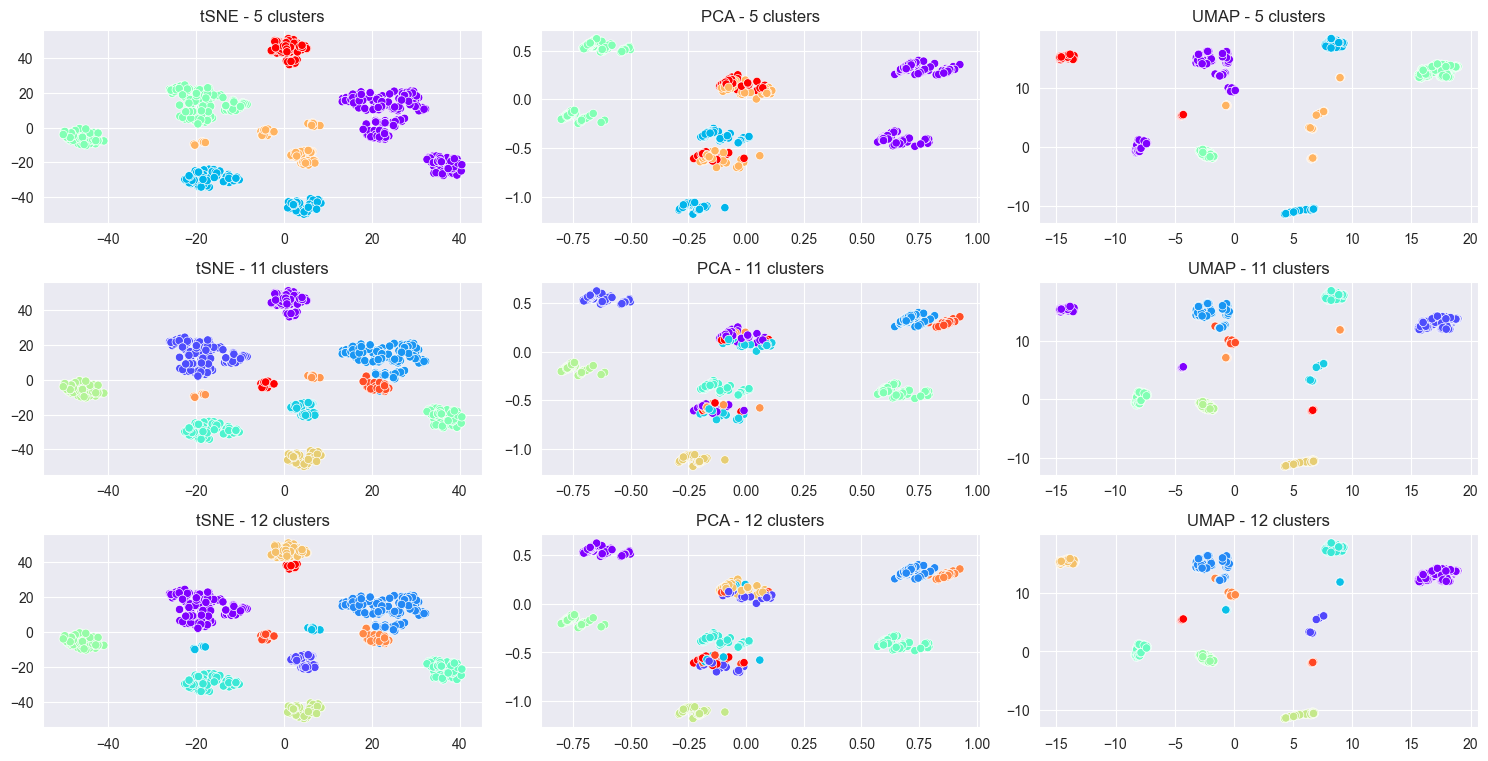

In [54]:
# первая тройка: 5, 11 либо 12 кластеров
cluster_coll = [5, 11, 12]
clustering_results["Hierarhical"] = {}

plt_col_count = len(reduction_methods)
plt_row_count = 1 + int(len(reduction_methods) * len(cluster_coll) / plt_col_count)
fig, axes = plt.subplots(plt_row_count, plt_col_count, figsize=(15, 10))
axes_iter = axes.flat
for cluster_count in cluster_coll:
    labels = AgglomerativeClustering(n_clusters=cluster_count).fit(dataset_num).labels_
    clustering_results["Hierarhical"][cluster_count] = labels

    for method_name, method in reduction_methods.items():
        axis = next(axes_iter)
        X = method.fit_transform(dataset_num)
        sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels, ax=axis, palette="rainbow", legend=False)
        axis.set_title(f"{method_name} - {cluster_count} clusters")
# удаляем незадействованные оси
for axis in axes_iter:
    fig.delaxes(axis)
# графики мы подписали, теперь нужно место для title
plt.tight_layout()
plt.show()

12 кажется избыточным, поскольку уже пошло разделение близких зон.

между 5 и 11 я бы выбрал 5. либо нужно смотреть больше вариантов/больше размерность

### DBSCAN

In [55]:
def dbscan_clustering(eps_range, X):
    eps_range = eps_range
    silhouette = []
    clusters = []
    for i in eps_range:
        dbscan = DBSCAN(eps=i).fit(X)
        labels = dbscan.labels_
        uniq_labels = np.unique(labels)
        n_clusters = len(uniq_labels[uniq_labels != -1])
        if n_clusters > 1:
            score = silhouette_score(X, labels)
        else:
            score = 0
        silhouette.append(score)
        clusters.append(n_clusters)

    fig, ax1 = plt.subplots()

    color = 'tab:red'
    ax1.plot(eps_range, silhouette, marker='o', color=color)
    ax1.set_xlabel('eps')
    ax1.set_ylabel('silhouette', color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

    color = 'tab:blue'
    ax2.plot(eps_range, clusters, marker='o', color=color)
    ax2.set_ylabel('n_clusters', color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.show()

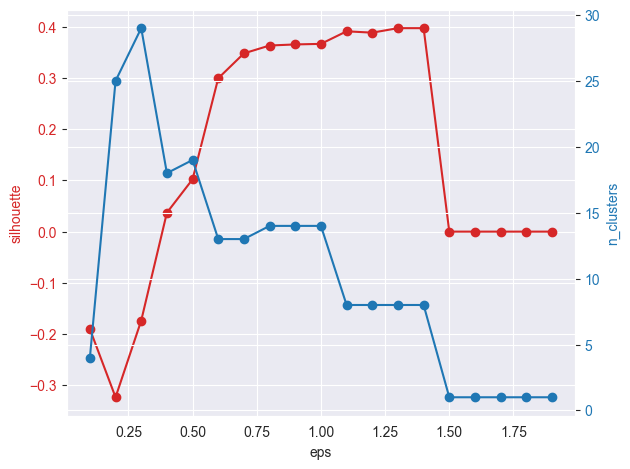

In [56]:
eps_range = np.arange(0.1 , 2, 0.1)
dbscan_clustering(eps_range, dataset_num)

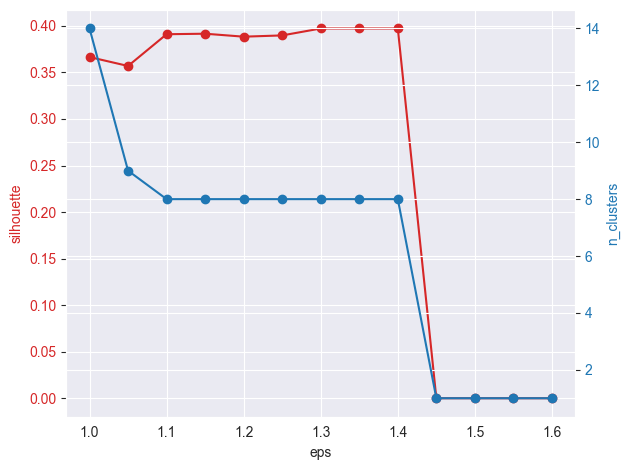

In [57]:
eps_range = np.arange(1.0 , 1.6, 0.05)
dbscan_clustering(eps_range, dataset_num)

8 кластеров, eps = 1.35

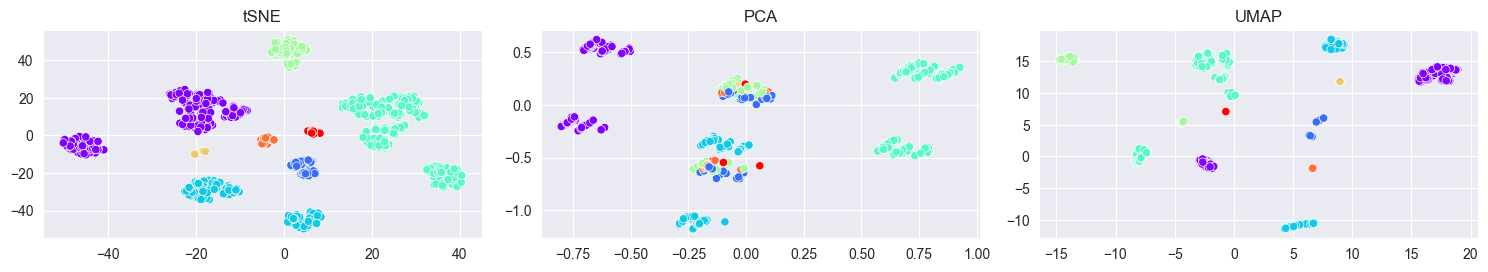

In [58]:
labels = DBSCAN(eps=1.35).fit(dataset_num).labels_
clustering_results["DBSCAN"] = {1.35: labels}

plt_col_count = len(reduction_methods)
plt_row_count = 1 + int(len(reduction_methods) * len(cluster_coll) / plt_col_count)
fig, axes = plt.subplots(plt_row_count, plt_col_count, figsize=(15, 10))
axes_iter = axes.flat

for method_name, method in reduction_methods.items():
    axis = next(axes_iter)
    X = method.fit_transform(dataset_num)
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels, ax=axis, palette="rainbow", legend=False)
    axis.set_title(f"{method_name}")
# удаляем незадействованные оси
for axis in axes_iter:
    fig.delaxes(axis)
# графики мы подписали, теперь нужно место для title
plt.tight_layout()
plt.show()

может не хватать размерности для оценки близости зон, но в текущем представлении деление не кажется удачным, поскольку сосредоточилось на выделении зон, различимых только по tSNE, а не зон различимых во всех 3х методах

# Интерпретация

деление на 4-5 кластеров по всем трем методам очень схоже, но дальнейшее деление существенно отличается

я рассмотрю деление на 7 кластеров методом KMeans, как компромиссный вариант между минимальным делением на 4-5 кластеров и, на мой взгляд, избыточным делением на 10-11 кластеров.

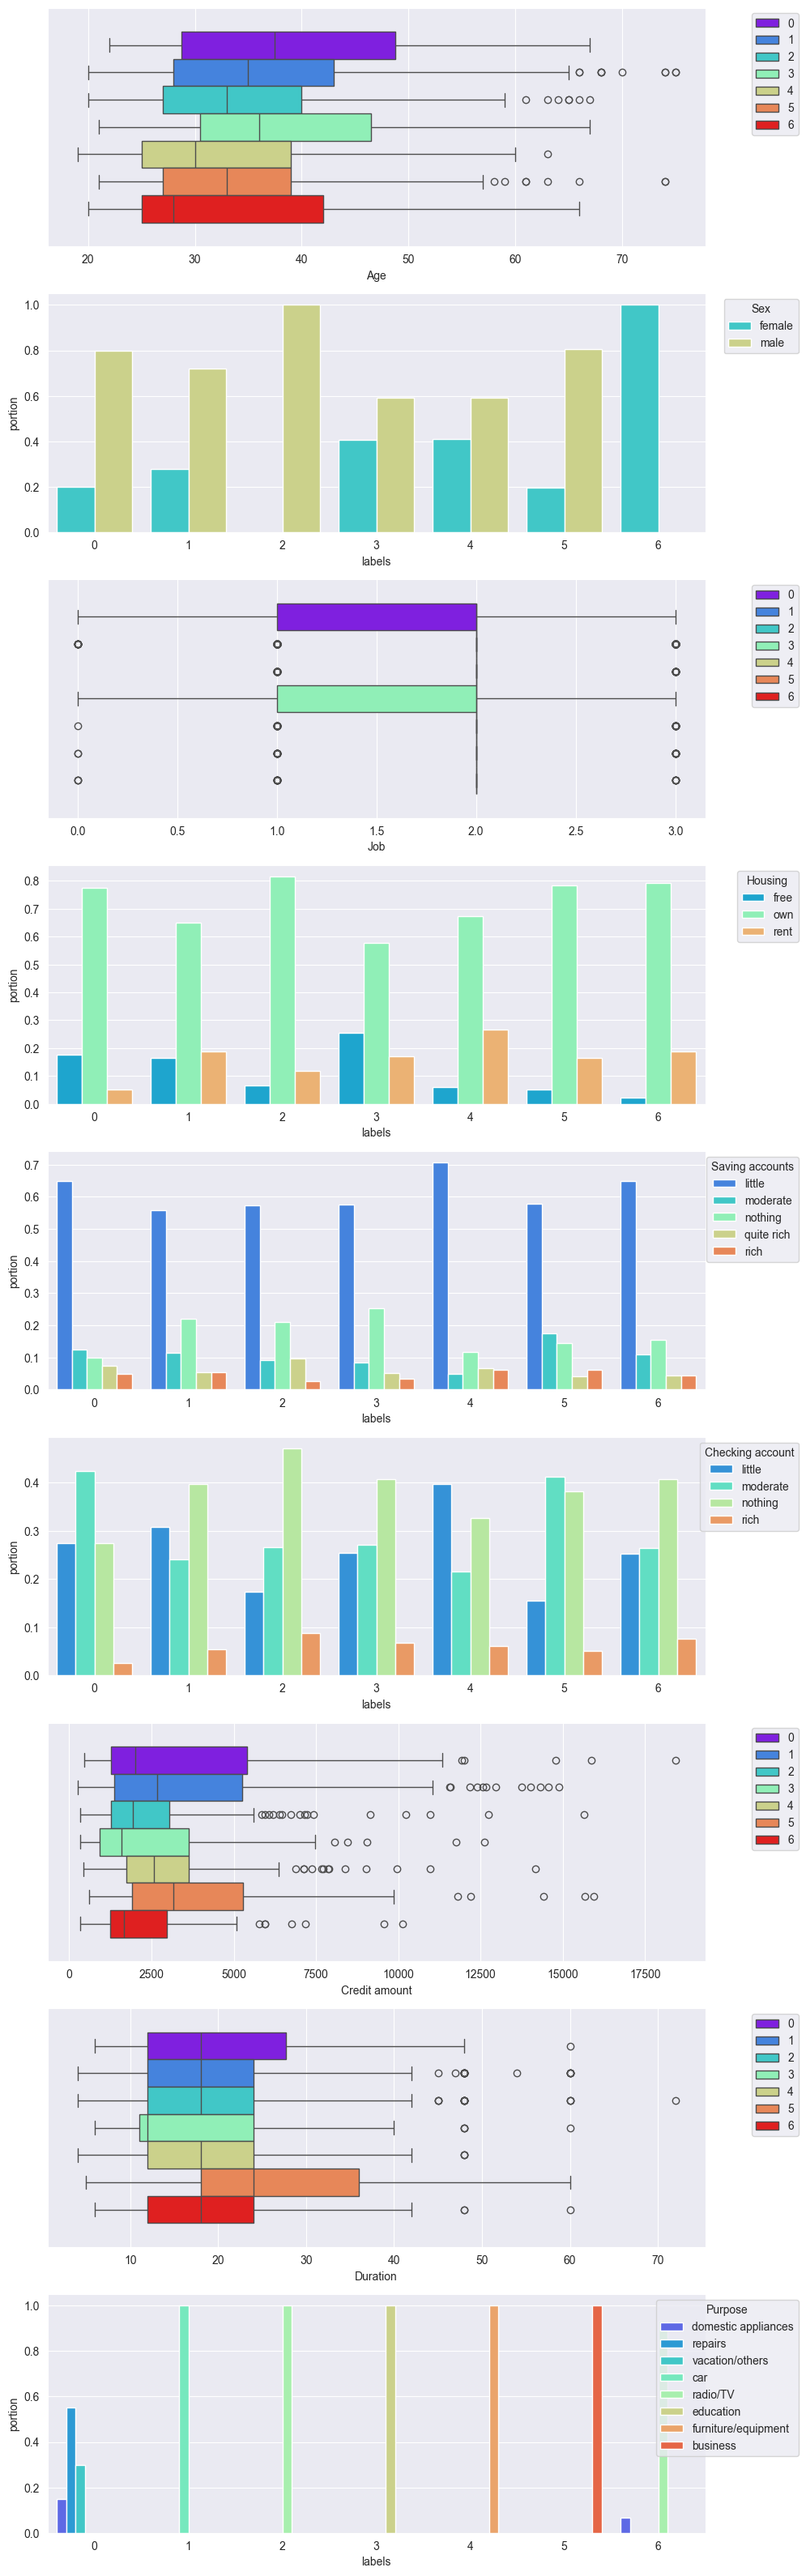

In [59]:
labels = clustering_results["KMeans"][7]
dataset_labeled = dataset_customer.copy()
dataset_labeled["labels"] = labels

features_lst = dataset_customer.columns.to_list()
features_num_lst = dataset_customer.select_dtypes(include=["number"]).columns.to_list()
plt_col_count = 1
plt_row_count = 1 + int(len(features_lst) / plt_col_count)
fig, axes = plt.subplots(plt_row_count, plt_col_count, figsize=(10, 35))
axes_iter = axes.flat

for column in features_lst:
    axis = next(axes_iter)
    if column in features_num_lst:
        graph = sns.boxplot(data=dataset_customer, x=dataset_customer[column], hue=labels, palette="rainbow", orient="h", ax=axis, legend="full")
    else:
        # приводим абсолютные значения к долям в группе
        dataset_portion = dataset_labeled[[column, "labels"]]
        dataset_portion["portion"] = 1 / dataset_portion.groupby("labels")[column].transform("count")
        dataset_plot = dataset_portion.groupby([column, "labels"])["portion"].sum().reset_index()
        graph = sns.barplot(data=dataset_plot, x="labels", y="portion", hue=column, palette="rainbow", ax=axis)
    sns.move_legend(graph, "upper right", bbox_to_anchor=(1.15, 1.0))
    # axis.set_title(f"{column}")
# удаляем незадействованные оси
for axis in axes_iter:
    fig.delaxes(axis)
# графики мы подписали, теперь нужно место для title
plt.tight_layout()
plt.show()

Разделение прошло по цели кредита. К сожалению, такое разделение не дает нам новых данных (это поле даже не расчетное). Если принципиально разделить иначе, то можно отмасштабировать цель кредита к меньшему диапазону (что бы снизить его значимость). Я же попробую посмотреть меньшее число кластеров, что бы увидеть как purpose будет группироваться.

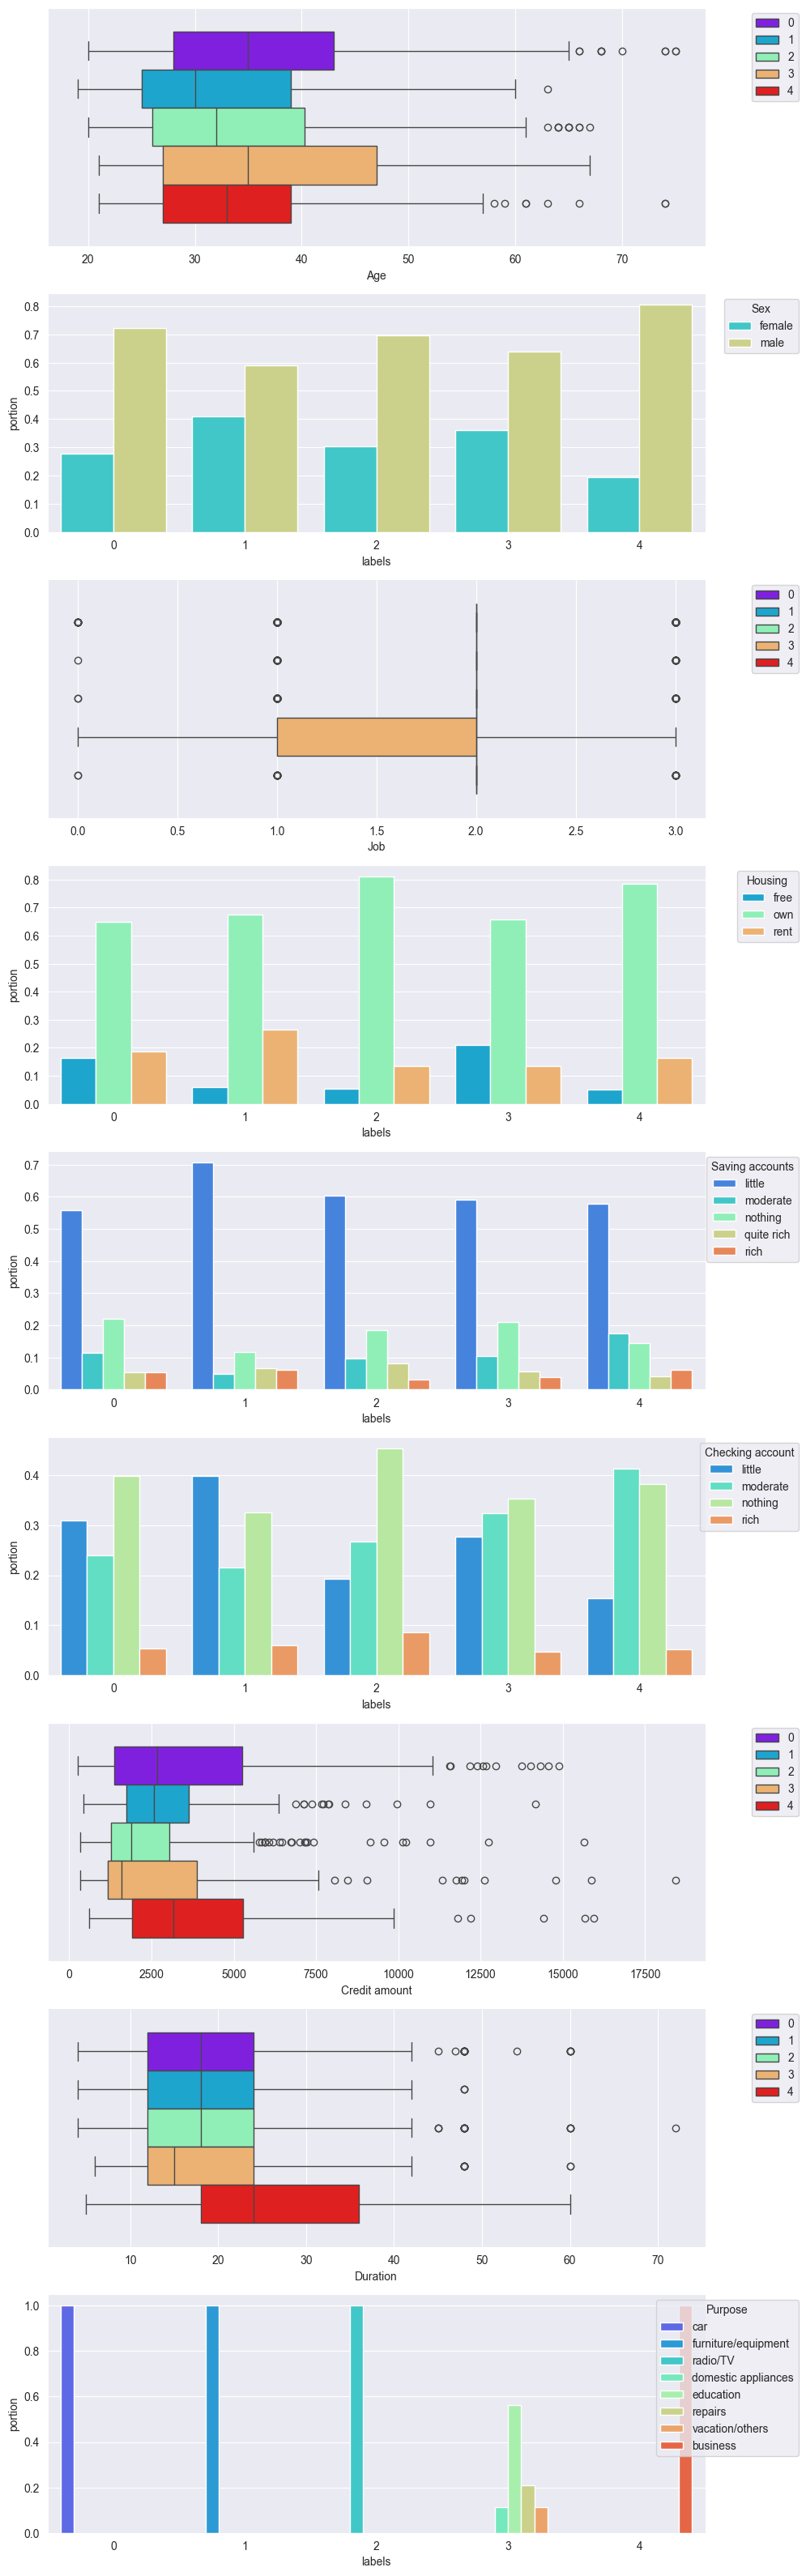

In [60]:
labels = clustering_results["Hierarhical"][5]
dataset_labeled = dataset_customer.copy()
dataset_labeled["labels"] = labels

features_lst = dataset_customer.columns.to_list()
features_num_lst = dataset_customer.select_dtypes(include=["number"]).columns.to_list()
plt_col_count = 1
plt_row_count = 1 + int(len(features_lst) / plt_col_count)
fig, axes = plt.subplots(plt_row_count, plt_col_count, figsize=(10, 35))
axes_iter = axes.flat

for column in features_lst:
    axis = next(axes_iter)
    if column in features_num_lst:
        graph = sns.boxplot(data=dataset_customer, x=dataset_customer[column], hue=labels, palette="rainbow", orient="h", ax=axis, legend="full")
    else:
        # приводим абсолютные значения к долям в группе
        dataset_portion = dataset_labeled[[column, "labels"]]
        dataset_portion["portion"] = 1 / dataset_portion.groupby("labels")[column].transform("count")
        dataset_plot = dataset_portion.groupby([column, "labels"])["portion"].sum().reset_index()
        graph = sns.barplot(data=dataset_plot, x="labels", y="portion", hue=column, palette="rainbow", ax=axis)
    sns.move_legend(graph, "upper right", bbox_to_anchor=(1.15, 1.0))
    # axis.set_title(f"{column}")
# удаляем незадействованные оси
for axis in axes_iter:
    fig.delaxes(axis)
# графики мы подписали, теперь нужно место для title
plt.tight_layout()
plt.show()


Интересно, что даже при объединении кластеров, 4 из 5 кластеров имеют четко выраженную цель. Видимо, варианты действительно качественно подобраны (или скорее подобрана выгрузка) и поле вполне качественно определяет тип заемщика.

Кластер 0: клиенты планирующие покупку машины. очень усредненная категория. самый большой разброс по сумме кредита.

Кластер 1: молодые клиенты использующие кредит для обстановки жилья. данных по мужчинам в целом больше, но в этой категории соотношение наиболее равное. люди еще не отложившие существенную сумму, но уже имеющие что-то на счету.

Кластер 2: так же молодые клиенты желающие обеспечить досуг покупкой электроники для равзлечений. интересно, что несмотря на возраст очень высокая доля housing own (возможно, сюда же попадают живущие с родителями). наименьшая сумма и небольшая длительность кредита.

Кластер 3: зрелые люди, использующие кредиты на различные нужды (в том числе обучение, вероятно детей). высокая доля job=1 (неполная занятость?). длительность и размер кредита так же относительно небольшие.

Кластер 4: клиенты расчитывающие использовать кредит для бизнеса. самая высокая доля мужчин. часто люди уже имеют не только деньги на счету, но и неплохие накопления. самая большая сумма и длительность кредита.